In [112]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [113]:
import sys
sys.path.append("../")

# Загрузка данных

In [5]:
import os
from typing import List
from datetime import datetime

from dotenv import load_dotenv
import pandas as pd

from fractal.loaders.thegraph.uniswap_v3 import EthereumUniswapV3Loader
from fractal.loaders.base_loader import LoaderType
from fractal.core.base import Observation
from examples.tau_strategy.tau_strategy import build_observations
from fractal.loaders.thegraph.uniswap_v3.uniswap_v3_pool import UniswapV3EthereumPoolHourDataLoader, UniswapV3EthereumPoolMinuteDataLoader
from fractal.loaders.binance import BinanceHourPriceLoader, BinanceMinutePriceLoader
from fractal.loaders.structs import PoolHistory, PriceHistory
from fractal.core.entities.uniswap_v3_lp import UniswapV3LPGlobalState



def get_observations(
        pool_data: PoolHistory, price_data: PriceHistory,
        start_time: datetime = None, end_time: datetime = None
    ) -> List[Observation]:
    """
    Get observations from the pool and price data for the TauResetStrategy.

    Returns:
        List[Observation]: The observation list for TauResetStrategy.
    """
    observations_df: pd.DataFrame = pool_data.join(price_data)
    observations_df = observations_df.dropna()
    # observations_df = observations_df.loc[start_time:end_time]
    if start_time is None:
        start_time = observations_df.index.min()
    if end_time is None:
        end_time = observations_df.index.max()
    observations_df = observations_df[observations_df.tvl > 0]
    observations_df = observations_df.sort_index()
    print(f"observations_df.columns {observations_df.columns}")
    return [
        Observation(
            timestamp=timestamp,
            states={
                'UNISWAP_V3': UniswapV3LPGlobalState(
                    price=price, 
                    tvl=tvls, 
                    volume=volume, 
                    fees=fees, 
                    liquidity=liquidity,
                    centralized_price=centralized_price,
                    open_price=open,
                    close_price=close,
                    high_price=high,
                    low_price=low,
                ),
            }
        ) for timestamp, (tvls, volume, fees, liquidity, price, open, high, low, close, centralized_price) in observations_df.iterrows()
    ]


def build_observations(
        ticker: str, pool_address: str, api_key: str,
        start_time: datetime = None, end_time: datetime = None, fidelity: str = 'hour',
    ) -> List[Observation]:
    """
    Build observations for the TauResetStrategy from the given start and end time.
    """
    if fidelity == 'hour':
        pool_data: PoolHistory = UniswapV3EthereumPoolHourDataLoader(
            api_key, pool_address, loader_type=LoaderType.CSV, start_time=start_time, end_time=end_time).read(with_run=True)
        binance_prices: PriceHistory = BinanceHourPriceLoader(ticker, loader_type=LoaderType.CSV).read(with_run=True)
        print(f"pool_data.columns {pool_data.columns}")
    elif fidelity == 'minute':
        pool_data: PoolHistory = UniswapV3EthereumPoolMinuteDataLoader(
            api_key, pool_address, loader_type=LoaderType.CSV).read(with_run=True)
        binance_prices: PriceHistory = BinanceMinutePriceLoader(ticker, loader_type=LoaderType.CSV,
                                                                start_time=start_time, end_time=end_time).read(with_run=True)

        
    return get_observations(pool_data, binance_prices, start_time, end_time)



load_dotenv()
ticker: str = 'ETHUSDT'
pool_address: str = '0x8ad599c3a0ff1de082011efddc58f1908eb6e6d8'
THE_GRAPH_API_KEY = os.getenv('THE_GRAPH_API_KEY')

# Load data
token0_decimals, token1_decimals = EthereumUniswapV3Loader(
    THE_GRAPH_API_KEY, loader_type=LoaderType.CSV).get_pool_decimals(pool_address)

# Build observations
observations: List[Observation] = build_observations(
    ticker=ticker, 
    pool_address=pool_address, 
    api_key=THE_GRAPH_API_KEY,
    start_time=datetime(2024, 3, 20), # min timestamp with fees > 0
    # start_time=datetime(2025, 3, 10), # min timestamp with fees > 0
    end_time=datetime(2025, 4, 16),
    fidelity='hour'
)
observation0 = observations[0]
observation0


current_loaded_time: 2024-04-30 17:00:00
current_loaded_time: 2024-06-12 02:00:00
current_loaded_time: 2024-07-24 08:00:00
current_loaded_time: 2024-09-04 07:00:00
current_loaded_time: 2024-10-17 15:00:00
current_loaded_time: 2024-11-29 00:00:00
current_loaded_time: 2025-01-10 03:00:00
current_loaded_time: 2025-02-20 22:00:00
current_loaded_time: 2025-04-03 13:00:00
current_loaded_time: 2025-04-17 13:00:00
pool_data.columns Index(['tvl', 'volume', 'fees', 'liquidity', 'token0_price', 'open', 'high',
       'low', 'close'],
      dtype='object')
observations_df.columns Index(['tvl', 'volume', 'fees', 'liquidity', 'token0_price', 'open', 'high',
       'low', 'close', 'price'],
      dtype='object')


Observation(timestamp=2024-03-19 21:00:00+00:00, states={'UNISWAP_V3': UniswapV3LPGlobalState(tvl=317256101.3949567, volume=536895.7831671502, fees=1610.6873495014509, liquidity=1.4513494727019018e+18, price=3285.5963803529758, centralized_price=3293.01, open_price=3279.179804687722, close_price=3285.5963803529758, high_price=3287.09640069871, low_price=3264.396181006303)})

In [6]:
token0_decimals, token1_decimals

(6.0, 18.0)

# Разделение на train\test

In [7]:
from typing import Tuple


def split_observations_by_time(
    observations: List[Observation],
    train_ratio: float = 0.7,
    test_ratio: float = 0.3
) -> Tuple[List[Observation], List[Observation]]:
    """
    Split observations into train and test sets by timestamp.
    The split is done chronologically to maintain the time sequence.
    
    Args:
        observations: List of observations to split
        train_ratio: Ratio of observations to use for training (default: 0.7)
        test_ratio: Ratio of observations to use for testing (default: 0.3)
        
    Returns:
        Tuple of (train_observations, test_observations)
        
    Raises:
        ValueError: If train_ratio + test_ratio != 1.0
    """
    if not (0 < train_ratio < 1 and 0 < test_ratio < 1):
        raise ValueError("train_ratio and test_ratio must be between 0 and 1")
    
    if abs(train_ratio + test_ratio - 1.0) > 1e-6:
        raise ValueError("train_ratio + test_ratio must equal 1.0")
    
    # Sort observations by timestamp to ensure chronological order
    sorted_observations = sorted(observations, key=lambda x: x.timestamp)
    
    # Calculate split indices
    total_obs = len(sorted_observations)
    train_size = int(total_obs * train_ratio)
    
    # Split observations
    train_observations = sorted_observations[:train_size]
    test_observations = sorted_observations[train_size:]
    
    return train_observations, test_observations
    


In [8]:
train_observations, test_observations = split_observations_by_time(observations)

In [191]:
len(train_observations)

6535

# Обучение

In [9]:
%env CLEARML_WEB_HOST=https://app.clear.ml/
%env CLEARML_API_HOST=https://api.clear.ml
%env CLEARML_FILES_HOST=https://files.clear.ml
# %env CLEARML_API_ACCESS_KEY=<Your access key>
# %env CLEARML_API_SECRET_KEY=<Your secret key>

%env CLEARML_API_ACCESS_KEY=75J86NR0W672MX1IMXSAW3Z74PKA4C
%env CLEARML_API_SECRET_KEY=1tnDAKa-O0bMYJPx89g5XuubsM3WoJr0vjH9z5DdLj4bwYhaF7uyx2To47WzLQWoSS4

env: CLEARML_WEB_HOST=https://app.clear.ml/
env: CLEARML_API_HOST=https://api.clear.ml
env: CLEARML_FILES_HOST=https://files.clear.ml
env: CLEARML_API_ACCESS_KEY=75J86NR0W672MX1IMXSAW3Z74PKA4C
env: CLEARML_API_SECRET_KEY=1tnDAKa-O0bMYJPx89g5XuubsM3WoJr0vjH9z5DdLj4bwYhaF7uyx2To47WzLQWoSS4


In [212]:
from fractal.strategies.rl_strategy import RLStrategy, RLStrategyParams


from clearml import Task

task = Task.init(
    project_name='AI_IN_BLOCKCHAIN', 
    task_name='UNISWAP_V3_LP_RL_STRATEGY',
    auto_resource_monitoring=False,
)


params = RLStrategyParams(
    INITIAL_BALANCE=1_000_000.0,
    LEARNING_RATE=0.001,
    N_STEPS=128,
    BATCH_SIZE=32,
    N_EPOCHS=100,
    GAMMA=0.99,
    GAE_LAMBDA=0.95,
    CLIP_RANGE=0.3,
)
RLStrategy.token0_decimals = token0_decimals
RLStrategy.token1_decimals = token1_decimals
RLStrategy.tick_spacing = 10

strategy = RLStrategy(params, debug=True)

print("Training...")
# Run the strategy on a sequence of observations
result = strategy.train(train_observations, total_timesteps=1e5)

task.close()

ClearML Task: created new task id=3a2376832a4045e1a37633a08aee889b
======> WARNING! Git diff too large to store (526kb), skipping uncommitted changes <======
ClearML results page: https://app.clear.ml/projects/ec648bc989a74c32b4a58e89c2a5e095/experiments/3a2376832a4045e1a37633a08aee889b/output/log
Training...
Logging to ./model_logs/run_34
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/Users/kbduvakin/ai_in_blockchain_project/fractal-defi/.venv/lib/python3.11/site-packages/stable_baselines3/common/env_checker.py:462: UserWarning:

We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html



--------------------------------------
| rollout/               |           |
|    ep_len_mean         | 499       |
|    ep_rew_mean         | -6.87e+06 |
| time/                  |           |
|    episodes            | 4         |
|    fps                 | 374       |
|    time_elapsed        | 5         |
|    total_timesteps     | 1996      |
| train/                 |           |
|    actor_loss          | 1.17e+05  |
|    critic_loss         | 6.82e+09  |
|    earned_fees         | 0         |
|    impermanent_loss    | 217       |
|    instantaneous_lvr   | 432       |
|    learning_rate       | 0.001     |
|    n_updates           | 1895      |
|    rebalancing_penalty | 564       |
--------------------------------------
--------------------------------------
| rollout/               |           |
|    ep_len_mean         | 499       |
|    ep_rew_mean         | -5.37e+06 |
| time/                  |           |
|    episodes            | 8         |
|    fps                 

In [196]:
# task.close()

In [213]:
strategy._remove_entity("UNISWAP_V3")
strategy.set_up()
strategy.deposited_initial_funds = False
result = strategy.run(test_observations)

In [214]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

from fractal.core.base.strategy.result import StrategyResult
from typing import Optional
    

def visualize_results(strategy_result: StrategyResult, save_path: Optional[str] = None):
    """
    Visualize the strategy results including price movement and liquidity boundaries.
    
    Args:
        strategy_result: The result from running the strategy
        save_path: Optional path to save the plot
    """
    # Convert timestamps to datetime objects
    timestamps = [pd.to_datetime(ts) for ts in strategy_result.timestamps]
    
    # Extract data
    prices = [state['UNISWAP_V3'].price for state in strategy_result.global_states]
    lower_bounds = [state['UNISWAP_V3'].price_lower for state in strategy_result.internal_states]
    upper_bounds = [state['UNISWAP_V3'].price_upper for state in strategy_result.internal_states]
    fees_earned = [state['UNISWAP_V3'].earned_fees for state in strategy_result.internal_states]
    
    # Create figure with subplots
    fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=True)
    
    # Plot price and boundaries
    ax.plot(timestamps, prices, label='Price', color='blue')
    ax.plot(timestamps, lower_bounds, label='Lower Bound', color='red', linestyle='--')
    ax.plot(timestamps, upper_bounds, label='Upper Bound', color='green', linestyle='--')
    
    # Fill between boundaries
    ax.fill_between(timestamps, lower_bounds, upper_bounds, color='gray', alpha=0.2)
    
    # Format price plot
    ax.set_ylabel('Price')
    ax.set_title('Price Movement and Liquidity Boundaries')
    ax.legend()
    ax.grid(True)
    
    plt.xticks(rotation=45)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save or show plot
    if save_path:
        plt.savefig(save_path)
    else:
        plt.show()
    
    plt.close()

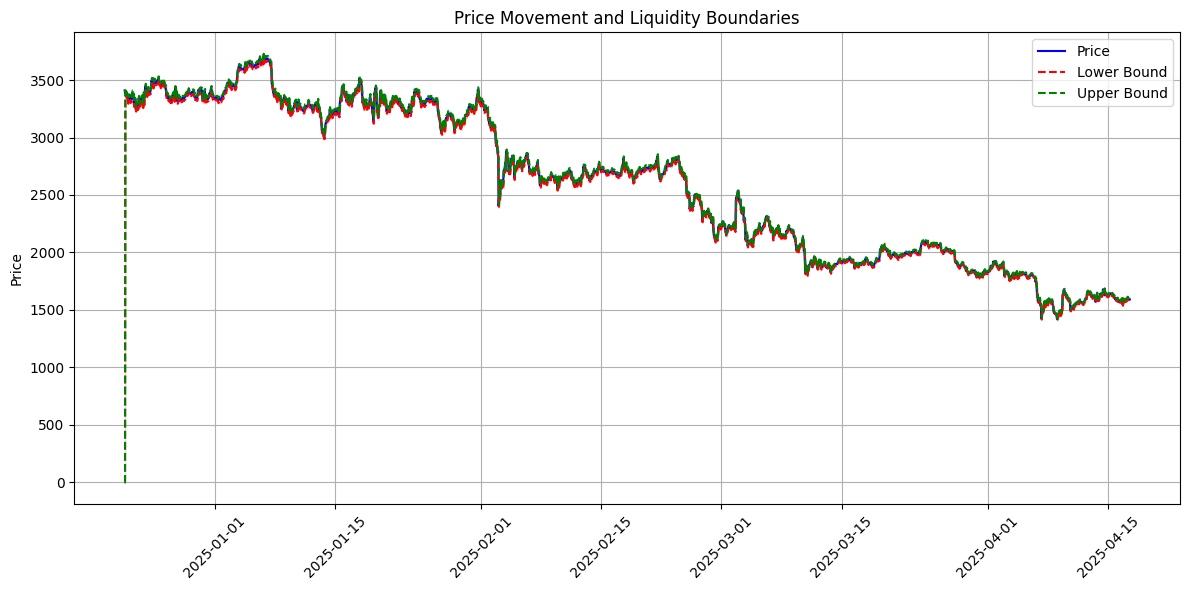

In [215]:
visualize_results(result)

In [216]:
result.get_default_metrics()

/Users/kbduvakin/ai_in_blockchain_project/fractal-defi/notebooks/../fractal/core/base/strategy/result.py:65: RuntimeWarning:

divide by zero encountered in scalar divide

/Users/kbduvakin/ai_in_blockchain_project/fractal-defi/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning:

invalid value encountered in subtract

/Users/kbduvakin/ai_in_blockchain_project/fractal-defi/notebooks/../fractal/core/base/strategy/result.py:80: RuntimeWarning:

invalid value encountered in divide



StrategyMetrics(accumulated_return=np.float64(inf), apy=np.float64(inf), sharpe=np.float64(nan), max_drawdown=np.float64(nan))

In [217]:
df = result.to_dataframe()
df

,timestamp,UNISWAP_V3_token0_amount,UNISWAP_V3_token1_amount,UNISWAP_V3_price_init,UNISWAP_V3_price_lower,UNISWAP_V3_price_upper,UNISWAP_V3_liquidity,UNISWAP_V3_cash,UNISWAP_V3_earned_fees,UNISWAP_V3_tvl,...,UNISWAP_V3_price,UNISWAP_V3_centralized_price,UNISWAP_V3_open_price,UNISWAP_V3_close_price,UNISWAP_V3_high_price,UNISWAP_V3_low_price,UNISWAP_V3_balance,UNISWAP_V3_token0_amount_init,UNISWAP_V3_token1_amount_init,net_balance
0,2024-12-21 12:00:00+00:00,0.000000,0.000000,0.000000,0.000000,0.000000,1.152051e+18,0.000000,0.000000,3.352097e+08,...,3409.980334,3402.05,3438.610444,3409.980334,3438.610444,3405.868204,0.000000,NaN,NaN,0.000000
1,2024-12-21 13:00:00+00:00,0.000000,0.000000,0.000000,0.000000,0.000000,1.430558e+18,1000000.000000,0.000000,3.350281e+08,...,3390.648006,3389.35,3409.935236,3390.648006,3409.935236,3358.411137,1000000.000000,NaN,NaN,1000000.000000
2,2024-12-21 14:00:00+00:00,313579.472528,202.511333,3390.648006,3370.087111,3410.769730,1.431459e+18,988.209892,988.209892,3.344380e+08,...,3382.799486,3373.91,3392.704956,3382.799486,3405.693726,3382.799486,999622.914349,506886.870305,144.997000,999622.914349
3,2024-12-21 15:00:00+00:00,751552.970087,72.555211,3382.799486,3362.345205,3402.934366,1.431459e+18,318.876825,318.876825,3.349769e+08,...,3392.885875,3389.12,3381.368149,3392.885875,3392.885875,3381.367601,998043.396472,503719.899142,145.271819,998043.396472
4,2024-12-21 16:00:00+00:00,0.000000,293.722023,3392.885875,3372.446880,3413.157985,1.237002e+18,0.000000,0.000000,3.337380e+08,...,3368.958180,3369.41,3390.721341,3368.958180,3390.721341,3368.958180,989537.213047,501051.257798,145.161385,989537.213047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2797,2025-04-17 09:00:00+00:00,9.794143,0.009981,1598.281764,1588.636650,1607.814166,3.283729e+18,0.009596,0.009596,2.436656e+08,...,1595.908060,1594.54,1597.530716,1595.908060,1597.530716,1595.908032,25.733169,12.986544,0.007959,25.733169
2798,2025-04-17 10:00:00+00:00,9.872768,0.009891,1595.908060,1586.255600,1605.404373,3.283746e+18,0.009309,0.009309,2.435066e+08,...,1593.599911,1592.91,1595.908060,1593.599911,1595.908075,1593.599904,25.644691,12.970853,0.007925,25.644691
2799,2025-04-17 11:00:00+00:00,12.833747,0.007991,1593.599911,1584.036507,1603.158492,3.283746e+18,0.000029,0.000029,2.435064e+08,...,1593.606152,1592.50,1593.599911,1593.606152,1593.606684,1593.599911,25.567836,12.825390,0.007972,25.567836
2800,2025-04-17 12:00:00+00:00,18.489664,0.004398,1593.606152,1584.036507,1603.158492,3.286288e+18,0.017096,0.017096,2.438020e+08,...,1597.874294,1600.93,1593.606163,1597.874294,1597.874362,1593.606163,25.534611,12.795261,0.007943,25.534611


In [218]:
df["UNISWAP_V3_earned_fees"].unique().sum()

np.float64(122728.06961885473)

# Centralized price and decentralized comparison

In [4]:
observations[0]

Observation(timestamp=2025-03-09 21:00:00+00:00, states={'UNISWAP_V3': UniswapV3LPGlobalState(tvl=300966885.4917675, volume=1913749.4990390132, fees=5741.24849711704, liquidity=5.612685138423769e+18, price=2022.9369570002336, centralized_price=2023.51, open_price=2045.213123345517, close_price=2022.9369570002336, high_price=2045.213123345517, low_price=2022.6012496692372)})

In [14]:
import numpy as np

token0_price = np.array([observation.states['UNISWAP_V3'].token0_price for observation in observations])
price = np.array([observation.states['UNISWAP_V3'].price for observation in observations])
timestamps = [observation.timestamp for observation in observations]

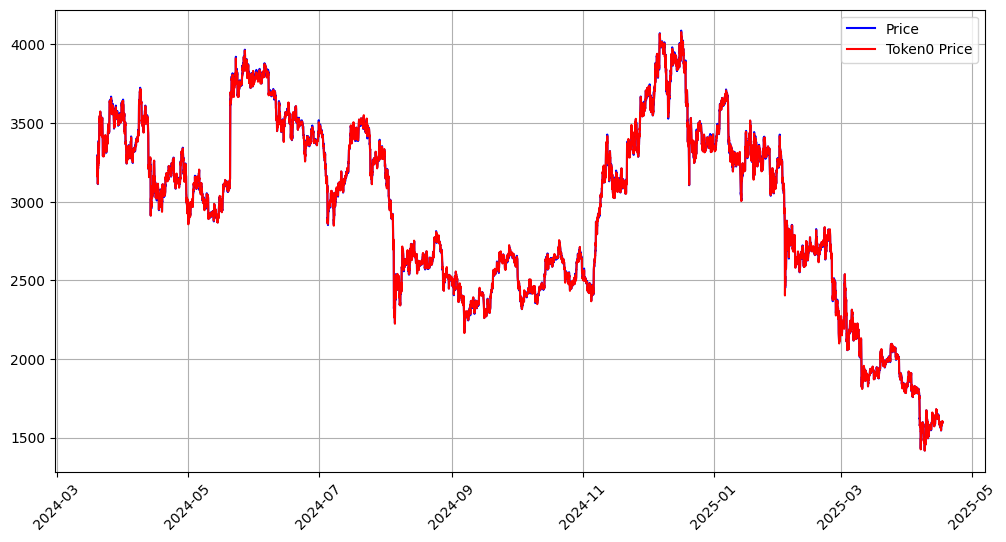

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=True)

# Plot price and boundaries
ax.plot(timestamps, price, label='Price', color='blue')
ax.plot(timestamps, token0_price, label='Token0 Price', color='red')
ax.legend()
ax.grid(True)

tmp = plt.xticks(rotation=45)


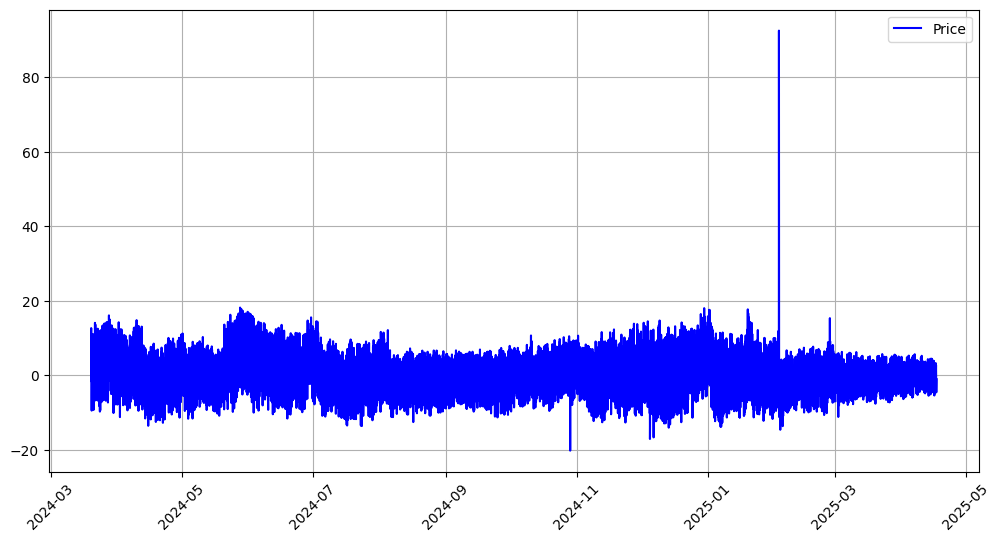

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=True)

# Plot price and boundaries
ax.plot(timestamps, price - token0_price, label='Price', color='blue')
ax.legend()
ax.grid(True)

tmp = plt.xticks(rotation=45)

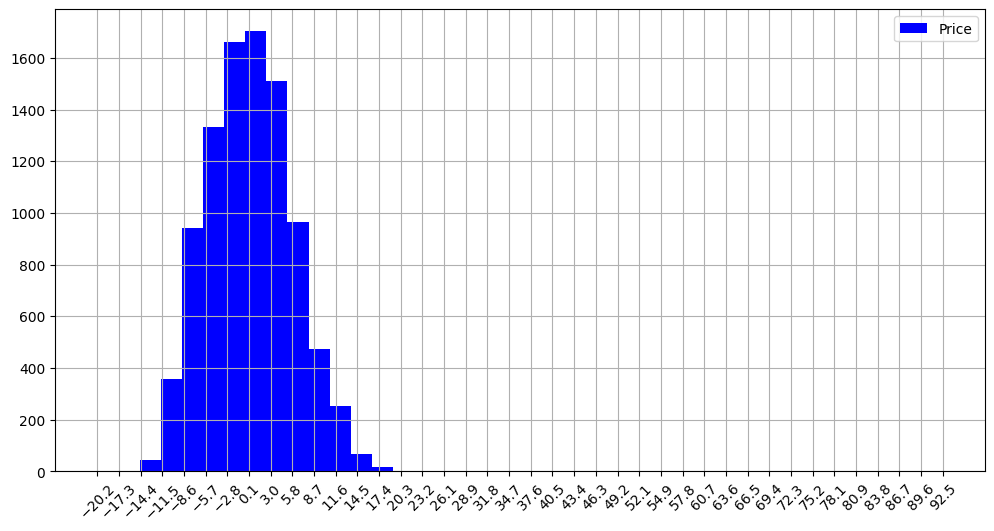

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=True)

# Plot price and boundaries
ax.hist(price - token0_price, label='Price', color='blue', bins=40)
ax.legend()
ax.grid(True)

ax.set_xticks(np.linspace(min(price - token0_price), max(price - token0_price), 40))

tmp = plt.xticks(rotation=45)



### Вывод

Как будто бы нужно использовать все-таки decetralized цены для всех манипуляций, а цены из binance использовать как фичу для модели.

# Tau-reset strategy

In [132]:
from fractal.strategies.tau_reset_strategy import TauResetStrategy, TauResetParams

params: TauResetParams = TauResetParams(TAU=10, INITIAL_BALANCE=1_000_000)
TauResetStrategy.token0_decimals = token0_decimals
TauResetStrategy.token1_decimals = token1_decimals
TauResetStrategy.tick_spacing = 60
strategy: TauResetStrategy = TauResetStrategy(debug=True, params=params)


# Run the strategy
result = strategy.run(test_observations)

In [133]:
df = result.to_dataframe()
df

,timestamp,UNISWAP_V3_token0_amount,UNISWAP_V3_token1_amount,UNISWAP_V3_price_init,UNISWAP_V3_price_lower,UNISWAP_V3_price_upper,UNISWAP_V3_liquidity,UNISWAP_V3_cash,UNISWAP_V3_earned_fees,UNISWAP_V3_tvl,UNISWAP_V3_volume,UNISWAP_V3_fees,UNISWAP_V3_price,UNISWAP_V3_balance,net_balance
0,2024-12-20 23:00:00+00:00,0.000000,0.000000,0.00,0.000000,0.000000,1.196445e+18,0.000000,0.000000,3.387732e+08,1.514085e+05,454.225432,3470.88,0.000000e+00,0.000000e+00
1,2024-12-21 00:00:00+00:00,0.000000,0.000000,0.00,0.000000,0.000000,1.136149e+18,1000000.000000,0.000000,3.377979e+08,1.236859e+05,371.057556,3456.18,1.000000e+06,1.000000e+06
2,2024-12-21 01:00:00+00:00,537846.646118,133.742405,3456.18,3254.917510,3669.887226,1.196445e+18,113.407835,113.407835,3.383953e+08,1.949635e+05,584.890366,3471.66,1.002268e+06,1.002268e+06
3,2024-12-21 02:00:00+00:00,542168.692541,132.497772,3456.18,3254.917510,3669.887226,1.196445e+18,167.685492,167.685492,3.389201e+08,9.331066e+04,279.931970,3473.43,1.002558e+06,1.002558e+06
4,2024-12-21 03:00:00+00:00,526022.540125,137.150676,3456.18,3254.917510,3669.887226,1.196445e+18,237.631168,237.631168,3.382499e+08,1.202461e+05,360.738321,3466.82,1.001737e+06,1.001737e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2791,2025-04-16 14:00:00+00:00,251132.908131,161.107108,1590.96,1498.314197,1689.334404,3.276818e+18,11233.459359,11233.459359,2.436100e+08,1.020461e+06,3061.382324,1590.00,5.185267e+05,5.185267e+05
2792,2025-04-16 15:00:00+00:00,250889.995832,161.259887,1590.96,1498.314197,1689.334404,3.277873e+18,11494.299710,11494.299710,2.436116e+08,1.411033e+06,4233.099339,1589.91,5.187730e+05,5.187730e+05
2793,2025-04-16 16:00:00+00:00,255692.985353,158.240657,1590.96,1498.314197,1689.334404,3.281922e+18,11659.914898,11659.914898,2.433440e+08,8.969446e+05,2690.833737,1591.69,5.192230e+05,5.192230e+05
2794,2025-04-16 17:00:00+00:00,128861.510056,239.118722,1590.96,1498.314197,1689.334404,3.364580e+18,12262.899601,12262.899601,2.402881e+08,3.342852e+06,10028.557143,1545.02,5.105676e+05,5.105676e+05


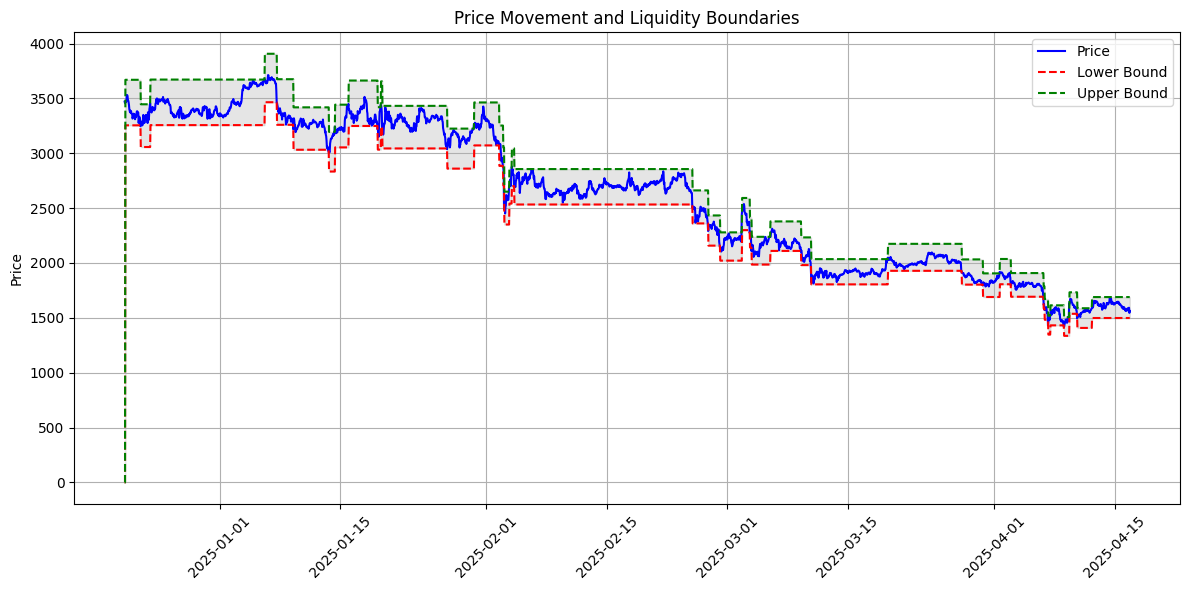

In [134]:
visualize_results(result)

In [135]:
df["UNISWAP_V3_earned_fees"].unique().sum()

np.float64(48587396.860676244)

In [136]:
result.get_default_metrics()

/Users/kbduvakin/ai_in_blockchain_project/fractal-defi/notebooks/../fractal/core/base/strategy/result.py:65: RuntimeWarning:

divide by zero encountered in scalar divide

/Users/kbduvakin/ai_in_blockchain_project/fractal-defi/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning:

invalid value encountered in subtract

/Users/kbduvakin/ai_in_blockchain_project/fractal-defi/notebooks/../fractal/core/base/strategy/result.py:80: RuntimeWarning:

invalid value encountered in divide



StrategyMetrics(accumulated_return=np.float64(inf), apy=np.float64(inf), sharpe=np.float64(nan), max_drawdown=np.float64(nan))